# ASEAN Internet Adoption Analysis (2010–2024)


## 1. Project Overview

Project ini bertujuan untuk menganalisis perkembangan penggunaan internet di negara ASEAN selama periode 2010-2024. Analisis dilakukan untuk mengidentifikasi tren penggunaan internet, mengukur hubungan antara jumlah populasi dan persentase penggunaan internet, mengamati perubahan yang terjadi antarperiode, serta perbedaan perkembangan populasi dan penggunaan internet yang terjadi antarnegara.



Data yang digunakan berasal dari [World Development Indicators (WDI) World Bank](https://databank.worldbank.org/source/world-development-indicators). Dataset mencakup 11 negara ASEAN, yaitu Indonesia, Malaysia, Singapore, Philippines, Brunei Darussalam, Thailand, Viet Nam, Cambodia, Lao PDR, Myanmar, dan Timor Leste. Dua indicator utama yang digunakan dalam project ini adalah Population, total dan Individuals using the Internet (% of population) dengan rentang tahun 2010 - 2024.  

## 2. Business Questions

1. Negara mana yang memiliki rata-rata Internet Usage tertinggi selama 2010–2024?

2. Negara mana yang mengalami peningkatan Internet Usage terbesar selama 2010–2024?

3. Apakah negara dengan peningkatan Internet Usage terbesar juga memiliki tingkat Internet Usage tertinggi pada 2024?

4. Pada tahun berapa masing-masing negara mengalami peningkatan tahunan Internet Usage terbesar selama 2010–2024?

5. Seberapa kuat dan bagaimana arah hubungan antara jumlah populasi dan tingkat penggunaan internet di negara-negara ASEAN pada 2024?

## 3. Data Source

Data : [World Development Indicators (WDI)](https://databank.worldbank.org/source/world-development-indicators)

Indicators : Individuals using the Internet (% of population) and Population, total

Countries    : 11 negara ASEAN

Period       : 2010–2024

Format       : CSV

## 4. Data Preparation & Data Cleaning

### 4.1 Load and Inspect Data

In [39]:
import pandas as pd

df = pd.read_csv("data/WDI_data.csv")

In [40]:
df.head()

,Country Name,Country Code,Series Name,Series Code,2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,Brunei Darussalam,BRN,Individuals using the Internet (% of population),IT.NET.USER.ZS,53.00,56.00,6.027310e+01,64.50,6.877000e+01,7.120000e+01,9.000000e+01,9.486670e+01,9.500000e+01,9.500000e+01,9.630550e+01,97.62879944,98.97042579,98.97039795,96.29828801
1,Brunei Darussalam,BRN,"Population, total",SP.POP.TOTL,392332.00,399389.00,4.055570e+05,411202.00,4.167500e+05,4.222120e+05,4.275640e+05,4.327720e+05,4.378100e+05,4.426800e+05,4.474040e+05,451721,455370,458949,462721
2,Cambodia,KHM,Individuals using the Internet (% of population),IT.NET.USER.ZS,1.26,3.10,4.940000e+00,6.00,1.400000e+01,6.433191e+00,3.239845e+01,3.290028e+01,6.500000e+01,5.230588e+01,5.637590e+01,60.76269913,65.49079895,68.92549896,68.47530365
3,Cambodia,KHM,"Population, total",SP.POP.TOTL,14500726.00,14722584.00,1.494508e+07,15170208.00,1.539677e+07,1.562325e+07,1.585280e+07,1.607337e+07,1.627452e+07,1.648130e+07,1.672547e+07,16974305,17201724,17423880,17638801
4,Indonesia,IDN,Individuals using the Internet (% of population),IT.NET.USER.ZS,10.92,12.28,1.452000e+01,14.94,1.714316e+01,2.206274e+01,2.544735e+01,3.233581e+01,3.990464e+01,4.769065e+01,5.372649e+01,62.10447842,66.48461277,69.20836554,72.78075544


In [41]:
df.tail()

,Country Name,Country Code,Series Name,Series Code,2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,Last Updated: 07/13/2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Raw dataset yang tersedia oleh WDI memperlihatkan tahun 2010 - 2024 sebagai kolom dan setiap barisnya mewakili satu negara dan satu indikator. Selain itu, terdapat beberapa baris metadata yang bukan merupakan bagian dari observasi.

### 4.2 Data Cleaning

In [43]:
df_clean = df[df["Country Code"].notna()]
df_clean.tail()

,Country Name,Country Code,Series Name,Series Code,2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
17,Thailand,THA,"Population, total",SP.POP.TOTL,68579447.00,69007208.00,6.943610e+07,69845114.0,70216367.0,70540795.0,7.085984e+07,7.116019e+07,7.137608e+07,7.152227e+07,7.164148e+07,71727332,71735329,71702435,71668011
18,Viet Nam,VNM,Individuals using the Internet (% of population),IT.NET.USER.ZS,30.65,35.07,3.680000e+01,38.5,41.0,45.0,5.300000e+01,5.814000e+01,6.984793e+01,6.866158e+01,7.030000e+01,74.20999985,78.58999918,78.08,84.15
19,Viet Nam,VNM,"Population, total",SP.POP.TOTL,87455152.00,88468314.00,8.951036e+07,90573104.0,91679578.0,92823254.0,9.400012e+07,9.517698e+07,9.623732e+07,9.717378e+07,9.807919e+07,98935098,99680655,100352192,100987686
20,Timor-Leste,TLS,Individuals using the Internet (% of population),IT.NET.USER.ZS,3.00,4.00,7.000000e+00,11.0,17.5,18.6,2.120000e+01,2.420000e+01,2.760000e+01,2.800460e+01,3.201270e+01,35.04199982,..,..,..
21,Timor-Leste,TLS,"Population, total",SP.POP.TOTL,1084679.00,1110207.00,1.134885e+06,1158695.0,1181903.0,1205131.0,1.228312e+06,1.251703e+06,1.275959e+06,1.300945e+06,1.326053e+06,1350139,1369295,1384286,1400638


Menghilangkan baris-baris data yang tidak digunakan sebagai bahan observasi.

In [44]:
print(df_clean["Country Name"].nunique())
print(df_clean["Series Name"].nunique())
print(df_clean.groupby("Country Name").size())

11
2
Country Name
Brunei Darussalam    2
Cambodia             2
Indonesia            2
Lao PDR              2
Malaysia             2
Myanmar              2
Philippines          2
Singapore            2
Thailand             2
Timor-Leste          2
Viet Nam             2
dtype: int64


In [45]:
df_clean.columns

Index(['Country Name', 'Country Code', 'Series Name', 'Series Code',
       '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]',
       '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]',
       '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]',
       '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]'],
      dtype='object')

In [46]:
year_columns = [
    col for col in df_clean.columns
    if "[YR" in col
]

year_columns

['2010 [YR2010]',
 '2011 [YR2011]',
 '2012 [YR2012]',
 '2013 [YR2013]',
 '2014 [YR2014]',
 '2015 [YR2015]',
 '2016 [YR2016]',
 '2017 [YR2017]',
 '2018 [YR2018]',
 '2019 [YR2019]',
 '2020 [YR2020]',
 '2021 [YR2021]',
 '2022 [YR2022]',
 '2023 [YR2023]',
 '2024 [YR2024]']

Mengidentifikasi dan menyimpan nama kolom tahun 2010–2024 ke dalam year_columns untuk digunakan pada proses transformasi data.

### 4.3 Data Transformation

In [47]:
df_long = df_clean.melt(
    id_vars= ['Country Name', 'Country Code','Series Name','Series Code'],
    value_vars= year_columns,
    var_name='Year',
    value_name='Value'
)

Melakukan transformasi data dari wide -> long. Hal ini bertujuan untuk mengubah year menjadi satu variabel, sehingga data lebih mudah untuk di filter, dikelompokkan, maupun dianalisis berdasarkan waktu.

In [48]:
print(df_long["Year"].head())
print(df_long["Year"].dtype)

0    2010 [YR2010]
1    2010 [YR2010]
2    2010 [YR2010]
3    2010 [YR2010]
4    2010 [YR2010]
Name: Year, dtype: object
object


In [49]:
df_long["Year"] = (df_long["Year"].str[:4].astype(int))

Setelah melakukan transformasi, format Year masih berupa 2010[YR2010], sehingga harus dihapus karena tidak diperlukan untuk proses analisis. Selain itu, tipe data Year diubah menjadi integer untuk bisa di filter dan diurutkan berdasarkan waktu.

In [50]:
df_pivot = df_long.pivot(
    index = ["Country Name", "Country Code","Year"],
    columns = "Series Name",
    values = "Value"
)

In [51]:
df_pivot.head()

Series Name                         Individuals using the Internet (% of population)  \
Country Name      Country Code Year                                                    
Brunei Darussalam BRN          2010                                             53.0   
                               2011                                             56.0   
                               2012                                        60.273102   
                               2013                                             64.5   
                               2014                                        68.769997   

Series Name                         Population, total  
Country Name      Country Code Year                    
Brunei Darussalam BRN          2010          392332.0  
                               2011          399389.0  
                               2012          405557.0  
                               2013          411202.0  
                               2014          416750.0

In [52]:
df_pivot = df_pivot.reset_index()

In [53]:
df_pivot.head()

Series Name,Country Name,Country Code,Year,Individuals using the Internet (% of population),"Population, total"
0,Brunei Darussalam,BRN,2010,53.0,392332.0
1,Brunei Darussalam,BRN,2011,56.0,399389.0
2,Brunei Darussalam,BRN,2012,60.273102,405557.0
3,Brunei Darussalam,BRN,2013,64.5,411202.0
4,Brunei Darussalam,BRN,2014,68.769997,416750.0


In [54]:
df_pivot.shape

(165, 5)

In [55]:
df_pivot = df_pivot.rename(
    columns = {
        "Individuals using the Internet (% of population)" : "Internet Usage",
        "Population, total" : "Population"
    }
)

In [56]:
df_pivot.head()

Series Name,Country Name,Country Code,Year,Internet Usage,Population
0,Brunei Darussalam,BRN,2010,53.0,392332.0
1,Brunei Darussalam,BRN,2011,56.0,399389.0
2,Brunei Darussalam,BRN,2012,60.273102,405557.0
3,Brunei Darussalam,BRN,2013,64.5,411202.0
4,Brunei Darussalam,BRN,2014,68.769997,416750.0


## 5. Exploratory Data Analysis (EDA)

In [57]:
df_pivot.groupby("Country Name").size()

,0
Country Name,
Brunei Darussalam,15
Cambodia,15
Indonesia,15
Lao PDR,15
Malaysia,15
Myanmar,15
Philippines,15
Singapore,15
Thailand,15


In [58]:
df_pivot.isnull().sum()

,0
Series Name,
Country Name,0
Country Code,0
Year,0
Internet Usage,0
Population,0


In [59]:
df_pivot.duplicated(
    subset=["Country Name", "Year"]
).sum()

np.int64(0)

In [60]:
df_pivot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Country Name    165 non-null    object
 1   Country Code    165 non-null    object
 2   Year            165 non-null    int64 
 3   Internet Usage  165 non-null    object
 4   Population      165 non-null    object
dtypes: int64(1), object(4)
memory usage: 6.6+ KB


In [61]:
df_pivot["Internet Usage"] = pd.to_numeric(
    df_pivot["Internet Usage"],
    errors="coerce"
)

df_pivot["Population"] = pd.to_numeric(
    df_pivot["Population"],
    errors="coerce"
)

In [62]:
df_pivot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    165 non-null    object 
 1   Country Code    165 non-null    object 
 2   Year            165 non-null    int64  
 3   Internet Usage  158 non-null    float64
 4   Population      165 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 6.6+ KB


In [63]:
df_pivot.isnull().sum()

,0
Series Name,
Country Name,0
Country Code,0
Year,0
Internet Usage,7
Population,0


In [64]:
df_pivot[df_pivot["Internet Usage"].isnull()][["Country Name","Year","Internet Usage"]]

Series Name,Country Name,Year,Internet Usage
86,Myanmar,2021,NaN
87,Myanmar,2022,NaN
88,Myanmar,2023,NaN
89,Myanmar,2024,NaN
147,Timor-Leste,2022,NaN
148,Timor-Leste,2023,NaN
149,Timor-Leste,2024,NaN


In [65]:
df_long[
    (df_long["Country Name"].isin(["Myanmar", "Timor-Leste"])) &
    (df_long["Year"] >= 2021) &
    (df_long["Series Name"] == "Individuals using the Internet (% of population)")
][["Country Name", "Year", "Value"]]

,Country Name,Year,Value
252,Myanmar,2021,..
262,Timor-Leste,2021,35.04199982
274,Myanmar,2022,..
284,Timor-Leste,2022,..
296,Myanmar,2023,..
306,Timor-Leste,2023,..
318,Myanmar,2024,..
328,Timor-Leste,2024,..


Pada proses data cleaning tidak ditemukan missing values. Namun, setelah dilakukan pengecekan tipe data, diketahui bahwa kolom internet usage dan population masih berupa tipe data object, sehingga tipe data harus diubah ke dalam bentuk float agar nilai-nya bisa digunakan untuk proses analisis.

Saat mengubah tipe data internet usage dan population ke float, ditemukan 7 missing values. Missing values tersebut terdapat pada negara Myanmar untuk periode 2021 - 2024 dan Timor-Leste untuk periode 2022 - 2024. Oleh karena itu, nilai tersebut tidak akan digunakan untuk memperkirakan nilai Internet Usage.

Alasan missing values tidak ditemukan saat melakukan proses data cleaning karena value yang terisi bukan bernilai 'NaN', melainkan '..' sehingga nilai tersebut dianggap valid oleh Pandas.

## 6. Analysis


### 6.1 Average Internet Usage by Country (2010-2024)

In [66]:
df_complete = df_pivot[~df_pivot["Country Name"].isin(["Myanmar", "Timor-Leste"])]

internet_avg = df_complete.groupby("Country Name")["Internet Usage"].mean().sort_values(ascending=False)
internet_avg


,Internet Usage
Country Name,
Singapore,84.833958
Brunei Darussalam,82.452213
Malaysia,78.574827
Viet Nam,57.466634
Thailand,55.402126
Philippines,46.536031
Indonesia,37.436604
Cambodia,35.891200
Lao PDR,34.194827


Singapore memiliki rata-rata internet usage tertinggi selama 2010 - 2024, yaitu di angka sekitar 84.83%, diikuti dengan negara Brunei Darussalam 82.45% dan Malaysia 78.57%. Sedangkan negara dengan rata-rata internet usage terendah berada pada Lao PDR (Laos), yaitu di kisaran 34.19%.

* Negara Myanmar dan Timor-Leste tidak ikut serta dalam perhitungan di atas dikarenakan Myanmar tidak mempunyai data internet usage pada periode 2021 - 2024 dan Timor-Leste pada periode 2022-2024.

### 6.2 Increase Internet Usage by Country (2010-2024)

In [67]:
df_change = df_complete[
    df_complete["Year"].isin([2010, 2024])
]

df_change = df_change.sort_values(
    ["Country Name", "Year"]
)

df_change = df_change.groupby("Country Name")["Internet Usage"].agg(
  **{
      "2010" : "first",
      "2024" : "last"
  }
)

df_change["Change"] = df_change["2024"] - df_change["2010"]

df_change = df_change.sort_values("Change", ascending=False)

df_change

,2010,2024,Change
Country Name,,,
Thailand,22.40,90.867188,68.467188
Cambodia,1.26,68.475304,67.215304
Indonesia,10.92,72.780755,61.860755
Lao PDR,7.00,65.592697,58.592697
Viet Nam,30.65,84.150000,53.500000
Brunei Darussalam,53.00,96.298288,43.298288
Philippines,25.00,67.263009,42.263009
Malaysia,56.30,98.020606,41.720606
Singapore,71.00,94.377572,23.377572


Hasil tabel tersebut menyatakan bahwa Thailand merupakan negara yang mengalami peningkatan tertinggi selama periode 2010 - 2024 sekitar 68.47 poin persentase, diikuti dengan Cambodia sekitar 67.22 poin persentase dan Indonesia sekitar 61.86 poin persentase. Sementara itu, Singapore mengalami peningkatan terendah, yaitu sekitar 23.38 poin persentase selama periode 2010 - 2024.

* Myanmar dan Timor-Leste tidak masuk dalam analisis di atas karena data Internet Usage tahun 2024 tidak tersedia.

### 6.3 Countries with the Largest Increase and Highest Internet Usage in 2024

In [68]:
increase_2024_ranking = df_change.sort_values("2024", ascending=False)
increase_2024_ranking

,2010,2024,Change
Country Name,,,
Malaysia,56.30,98.020606,41.720606
Brunei Darussalam,53.00,96.298288,43.298288
Singapore,71.00,94.377572,23.377572
Thailand,22.40,90.867188,68.467188
Viet Nam,30.65,84.150000,53.500000
Indonesia,10.92,72.780755,61.860755
Cambodia,1.26,68.475304,67.215304
Philippines,25.00,67.263009,42.263009
Lao PDR,7.00,65.592697,58.592697


Hasil tabel menunjukkan bahwa Thailand mengalami peningkatan Internet Usage tertinggi selama periode 2010–2024, yaitu sekitar 68,47 poin persentase. Namun, Thailand bukan negara dengan tingkat Internet Usage tertinggi pada 2024. Malaysia menempati posisi tertinggi dengan Internet Usage sekitar 98,02%, meskipun peningkatannya selama 2010–2024 hanya sekitar 41,72 poin persentase.

### 6.4 Largest annual increase in Internet usage

In [69]:
annual_change = df_pivot.sort_values(["Country Name","Year"])
annual_change["Annual Change"] = annual_change.groupby("Country Name")["Internet Usage"].diff()
annual_change = annual_change[["Country Name","Year","Internet Usage","Annual Change"]]
annual_change

Series Name,Country Name,Year,Internet Usage,Annual Change
0,Brunei Darussalam,2010,53.000000,NaN
1,Brunei Darussalam,2011,56.000000,3.000000
2,Brunei Darussalam,2012,60.273102,4.273102
3,Brunei Darussalam,2013,64.500000,4.226898
4,Brunei Darussalam,2014,68.769997,4.269997
...,...,...,...,...
160,Viet Nam,2020,70.300000,1.638420
161,Viet Nam,2021,74.210000,3.910000
162,Viet Nam,2022,78.589999,4.379999
163,Viet Nam,2023,78.080000,-0.509999


In [70]:
max_index = (
    annual_change.groupby("Country Name")["Annual Change"].idxmax()
)
annual_max = annual_change.loc[max_index]
annual_max.sort_values("Annual Change", ascending = False)

Series Name,Country Name,Year,Internet Usage,Annual Change
23,Cambodia,2018,65.000000,32.099721
6,Brunei Darussalam,2016,90.000000,18.800003
101,Philippines,2021,66.907799,13.142899
158,Viet Nam,2018,69.847929,11.707929
130,Thailand,2020,77.843741,11.191321
54,Lao PDR,2019,47.032299,10.760998
85,Myanmar,2020,45.447701,8.907200
108,Singapore,2013,80.902100,8.902100
41,Indonesia,2021,62.104478,8.377984
66,Malaysia,2016,78.788310,7.724242


Selama periode 2010 - 2024, Cambodia merupakan negara dengan peningkatan internet usage tertinggi, yaitu pada tahun 2018 di angka 32.10 poin persentase, diikuti dengan Brunei Darussalam di tahun 2016 sekitar 18.80 poin persentase, dan Philippines di tahun 2021 sekitar 13.14 poin persentase.

* Myanmar dan Timor-Leste masuk ke dalam analisis di atas namun dengan ketersediaan data "Tahun" yang terbatas

### 6.5 Relationship between Population and Internet Usage in 2024

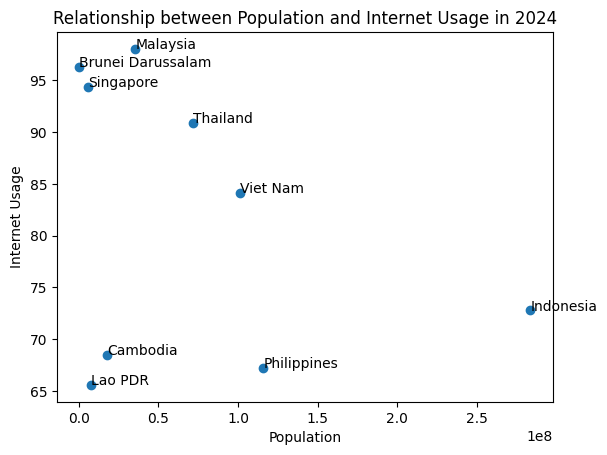

In [71]:
import matplotlib.pyplot as plt

df_complete_2024 = df_complete[df_complete["Year"] == 2024]

plt.scatter(
    df_complete_2024["Population"],
    df_complete_2024["Internet Usage"]
)

for _, row in df_complete_2024.iterrows():
    plt.annotate(
        row["Country Name"],
        (row["Population"], row["Internet Usage"])
    )

plt.xlabel("Population")
plt.ylabel("Internet Usage")
plt.title("Relationship between Population and Internet Usage in 2024")

plt.show()


In [72]:
df_complete_2024["Population"].corr(df_complete_2024["Internet Usage"])

np.float64(-0.3254995969585452)

Hasil analisis menyatakan bahwa adanya korelasi linear yang lemah hantara population dan internet usage, dengan nilai r = -0.325. Hal ini menunjukkan bahwa negara dengan populasi terbesar cenderung memiliki tingkat internet usage yang lebih rendah.

Scatter plot juga memperlihatkan Indonesia dengan populasi terbanyak namun persentase internet usage berada di kisaran 75%, sedangkan Malaysia dengan total populasi lebih sedikit mempunyai tingkat persentase internet usage tertinggi. Di sisi lain, negara seperti Lao PDR, Cambodia, dan Philippines tetap memiliki tingkat internet usage yang jauh lebih rendah daripada Malaysia, yaitu di kisaran 65-70%.

## 7. Key Findings & Insights

1. Negara dengan rata-rata internet usage tertinggi selama periode 2010-2024 adalah Singapore, diikuti Brunei Darussalam dan Malaysia. Negara dengan rata-rata terendah adalah Lao PDR.

2. Negara dengan peningkatan internet usage tertinggi selama periode 2010-2024 adalah Thailand, diikuti Cambodia dan Indonesia. Negara dengan peningkatan internet usage terendah adalah Singapore.

3. Thailand mengalami peningkatan Internet Usage terbesar selama periode 2010–2024. Namun, Malaysia memiliki tingkat Internet Usage tertinggi pada 2024. Hal ini menunjukkan bahwa negara dengan peningkatan terbesar selama periode tersebut tidak selalu memiliki tingkat Internet Usage tertinggi pada akhir periode.

4. Cambodia mencatat peningkatan tahunan Internet Usage terbesar di antara negara ASEAN, yaitu sekitar 32,10 poin persentase pada 2018 dibandingkan tahun sebelumnya.

5. Population dan Internet Usage pada tahun 2024 menunjukkan nilai korelasi negatif yang lemah dengan nilai r = -0.325. Hal ini menunjukkan bahwa negara dengan populasi yang besar cenderung memiliki tingkat internet usage yang rendah berdasarkan hasil analisis.

6. Lao PDR, Cambodia, dan Philippines adalah negara yang memiliki populasi yang rendah namun juga tingkat persentase internet usage yang juga rendah.

## 8. Limitations

1. Analisis hanya menggunakan data dari World Development Indicators (WDI), sehingga hasil bergantung pada ketersediaan data, definisi indikator, dan metodologi yang digunakan oleh sumber tersebut.

2. Myanmar dan Timor-Leste memiliki keterbatasan dari segi internet usage, yaitu periode 2021 - 2024 pada Myanmar dan periode 2022 - 2024 pada Timor-Leste.

3. Perbandingan negara ASEAN hanya berada di jangkauan periode 2010 - 2024, hasil analisis bisa berbeda jika dibandingkan dengan tahun sebelum maupun setelahnya.

4. Analisis hubungan Population dan Internet Usage hanya mengukur korelasi dan tidak menunjukkan hubungan sebab-akibat. Faktor lain yang mungkin berkaitan dengan tingkat penggunaan internet tidak dianalisis dalam project ini.

## 9. Conclusion

Berdasarkan hasil analisis yang telah dilakukan, negara-negara ASEAN menunjukkan pola perkembangan penggunaan internet yang berbeda-beda selama periode 2010–2024. Negara dengan populasi terbesar belum tentu merupakan negara dengan tingkat penggunaan internet tertinggi. Di sisi lain, negara dengan tingkat penggunaan internet tertinggi selama periode tersebut tidak selalu menjadi negara dengan peningkatan Internet Usage terbesar karena setiap negara memiliki tingkat awal dan ruang pertumbuhan yang berbeda.

Selain itu, hasil analisis pada 2024 menunjukkan adanya korelasi negatif yang lemah antara Population dan Internet Usage. Hal ini menunjukkan bahwa jumlah populasi saja tidak cukup untuk menjelaskan perbedaan tingkat penggunaan internet antarnegara ASEAN. Oleh karena itu, diperlukan analisis terhadap faktor-faktor lain di luar cakupan project ini untuk memahami perbedaan tersebut secara lebih menyeluruh.